<a href="https://colab.research.google.com/github/dangminhquandk/Email_Spam_Classification/blob/main/Project_report_N29_DK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Báo cáo Project
Lớp TTNT-162279, Nhóm G29

## 1. Thông tin chung



### Thành viên
- Đặng Minh Quân - 202416323
- Lê Quang Phúc - 202416316
- Hồ Sỹ Toàn - 202416368
- Hoàng Đặng Xuân Mỹ - 202416295

### Lịch thực hiện
- W02: Đăng ký nhóm
- W03: Đề xuất project (28/9)
- W08: Báo cáo tiến độ giữa kỳ (1/11)
- W15: Hoàn thành và gửi báo cáo project (20/12)
- W16-18: Trình bày project, Q&A

## 2. Đề xuất project (W3)

### Bài toán: ***Phân loại thư rác bằng thuật toán Naive Bayes và KNN***

### Bộ dữ liệu: [Email Spam Classification Dataset](https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv/data)

### Phương pháp
1.  **Thu thập dữ liệu**
2.  **Tiền xử lý dữ liệu**
3.  **Trích xuất đặc trưng**
4.  **Xây dựng mô hình**
5.  **Đánh giá mô hình**
6.  **So sánh kết quả**

### Phân công

| Mảng Công Việc | Người Phụ Trách | Công Việc Cụ Thể |
| :--- | :--- | :--- |
| **1. Dữ liệu** | Lê Quang Phúc<br>Hồ Sỹ Toàn | - Tìm kiếm và lựa chọn dataset.<br>- Tiền xử lý dữ liệu (làm sạch, chuẩn hóa, tách từ, loại bỏ stop words).<br>- Trích xuất đặc trưng (TF-IDF/BoW).<br>- Chia dữ liệu thành tập train/test.<br>- Viết báo cáo về phần dữ liệu. |
| **2. Thuật toán Naive Bayes** | Hồ Sỹ Toàn<br>Đặng Minh Quân | - Nghiên cứu sâu về thuật toán Naive Bayes.<br>- Xây dựng mô hình.<br>- Huấn luyện và kiểm thử mô hình.<br>- Viết báo cáo phần chương trình và kết quả của Naive Bayes. |
| **3. Thuật toán KNN** | Lê Quang Phúc<br>Hoàng Đặng Xuân Mỹ | - Nghiên cứu sâu về thuật toán KNN.<br>- Xây dựng mô hình.<br>- Huấn luyện và kiểm thử mô hình.<br>- Viết báo cáo phần chương trình và kết quả của KNN. |
| **4. Tổng hợp & Đánh giá**| Hoàng Đặng Xuân Mỹ<br>Đặng Minh Quân | - Nghiên cứu và áp dụng các độ đo hiệu năng (accuracy, precision, recall, F1-score).<br>- Tổng hợp và so sánh kết quả từ hai mô hình.<br>- Phân tích, đánh giá, và đề xuất hướng cải tiến.<br>- Tổng hợp, hoàn thiện báo cáo giữa kỳ và cuối kỳ.<br>- Chuẩn bị nội dung thuyết trình. |

## 3. Tiến độ giữa kỳ (W8)

### Chương trình

#### Tiền xử lý dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/emails.csv')
df.head()

In [ ]:
# Drop the unnecessary column

df.drop(columns=['Email No.'], inplace=True)

In [ ]:
# Check for null values

df.isnull().sum().sum()

In [ ]:
# Check for duplicates values

df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Prediction', data=df, hue='Prediction', palette='viridis', legend=False)
plt.title("Spam vs Ham Distribution")
plt.xlabel("0=Ham , 1=Spam")
plt.show()

- Tập dữ liệu vốn mất cân bằng với số lượng mail Ham nhiều gần gấp đôi số Spam, khiến cho việc dự đoán có khuynh hướng thiên về Ham.
- Vì vậy, cần undersample dữ liệu để dữ liệu cân bằng hơn.

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X, y

In [ ]:
# Number of columns to plot
num_columns = 12

# Create a figure and axes
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Get indices for spam and ham from y
spam_indices = (y == 1)
ham_indices = (y == 0)

# Loop through the first 12 columns and create distribution plots for spam and ham
for i, col_idx in enumerate(range(num_columns)):
    col_name = df.columns[col_idx] # Get original column name for title

    # Plot for ham emails
    sns.histplot(X[ham_indices, col_idx], ax=axes[i], kde=True, color='blue', label='Ham')
    # Plot for spam emails
    sns.histplot(X[spam_indices, col_idx], ax=axes[i], kde=True, color='red', label='Spam')
    axes[i].set_title(col_name)
    axes[i].legend()

# Adjust the layout
plt.tight_layout()
plt.show()


- Các biểu đồ có phân bố lệch phải mạnh. Đặc biệt, spam thường có đuôi dài, thể hiện các mail có tần suất xuất hiện một từ cụ thể rất cao thường sẽ là spam.
- Trong một số biểu đồ của từ vô nghĩa (Ví dụ: "ect", "hou" - có thể do sai chính tả), tần suất xuất hiện các từ này nghiêng về Ham hơn Spam.
- Các từ stopwords (Ví dụ: "the", "and", "a") có biểu đồ Ham và Spam gần trùng nhau, chứng tỏ các từ này ít mang giá trị trong việc phân biệt mail.

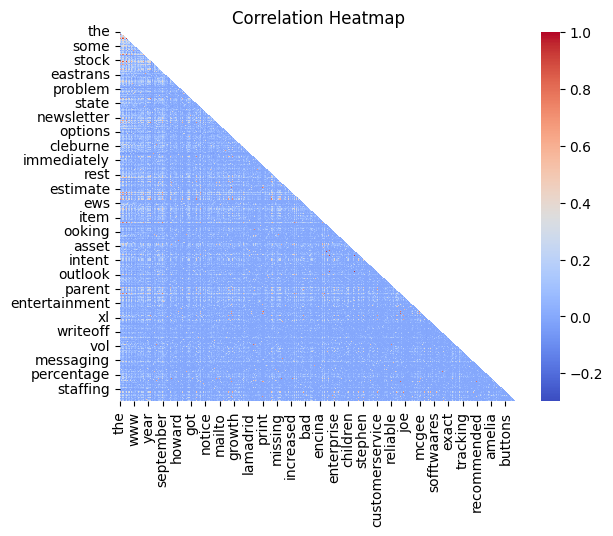

In [ ]:
# Calculate the correlation matrix for the dataset
correlation_matrix = df.corr()

# Build a matrix of booleans (True, False) with the same shape as the data
ones_corr = np.ones_like(correlation_matrix, dtype=bool)

# The variable mask now contains the upper triangular matrix mask created in the previous step
mask = np.triu(ones_corr)

# Create a heatmap to visualize the correlation matrix
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap="coolwarm")

# Customize the plot
plt.title("Correlation Heatmap")
plt.show()

Bản đồ nhiệt thể hiện hầu hết các từ có mối tương quan rất thấp, chủ yếu chỉ tương quan ở mức màu xanh nhạt và trắng. Ngoài ra, vẫn có vài cặp từ có mối tương quan cao (màu đỏ) tuy nhiên số lượng là không đáng kể.

In [ ]:
# Split into train, validation and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
y.shape, y_train.shape, y_val.shape, y_test.shape

((4631,), (2963,), (741,), (927,))

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

# Resample the train set
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print("Original class distribution:")
print(pd.Series(y_train).value_counts())

print("\nResampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Original class distribution:
0    2028
1     935
Name: count, dtype: int64

Resampled class distribution:
0    935
1    935
Name: count, dtype: int64


#### Huấn luyện mô hình

In [ ]:
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##### Naive Bayes

In [ ]:
# @title
class Naive_Bayes_raw: #raw code

  def __init__(self,laplace_smoothing):
    self.laplace_smoothing = laplace_smoothing
    self.label = []
    self.prior = {}
    self.log = {}

  def fit(self, X, y):
    self.label.append(0)
    self.label.append(1)

    n_emails, n_features = X.shape

    for c in self.label:
      self.prior[c] = 0
      word_counts = np.zeros(n_features)
      total_words = 0
      for x in range(n_emails):
        if y[x] == c:
          self.prior[c]+=1
          for i in range(n_features):
            word_counts[i] += X[x][i]

      for i in range(n_features):
        word_counts[i] += self.laplace_smoothing
        total_words += word_counts[i]

      res = np.zeros(n_features)

      self.log[c] = np.log(word_counts/total_words)
      self.prior[c] = np.log(self.prior[c]/n_emails)

  def predict(self, X_test):
    result = [self.single_predict(x) for x in X_test]
    return result

  def single_predict(self, x_test):
    res = -np.inf
    label = None
    for c in self.label:
      temp = np.dot(x_test,self.log[c]) + self.prior[c]
      if(temp > res):
        res = temp
        label = c
    return label

In [ ]:
class Naive_Bayes:
    def __init__(self, laplace_smoothing=1.0):
        # Hệ số làm trơn để tránh lỗi nhân cho 0 hoặc log(0)
        self.laplace_smoothing = laplace_smoothing

        # Lưu xác suất tiên nghiệm P(c) - VD: P(Spam), P(Ham)
        self.prior_probs = {}

        # Lưu log xác suất có điều kiện log P(w|c) cho từng từ trong từng lớp
        self.log_likelihood = {}

        # Danh sách các nhãn [0, 1]
        self.classes = []

    def fit(self, X, y):
        n_samples, n_features = X.shape # Số dòng (email), Số cột (từ)
        self.classes = np.unique(y)     # Tìm các nhãn duy nhất: [0, 1]

        for c in self.classes:
            # Lấy tất cả các dòng email thuộc nhãn c (VD: Lấy hết Spam)
            X_c = X[y == c]

            # P(c) = Số lượng email lớp c / Tổng số email
            self.prior_probs[c] = X_c.shape[0] / n_samples

            # Tổng số lần xuất hiện của TỪNG từ trong toàn bộ email lớp c
            # word_counts: Mảng 1 chiều chứa tổng từng cột
            word_counts = np.sum(X_c, axis=0) + self.laplace_smoothing

            # Tổng số từ (tất cả các từ) trong lớp c + phần bù Laplace
            total_counts = np.sum(word_counts)

            # Tính Log xác suất để tránh số quá nhỏ (Underflow)
            # log( P(w|c) )
            self.log_likelihood[c] = np.log(word_counts / total_counts)

    def predict(self, X):
        result = [self._predict_single(x) for x in X]
        return np.array(result)

    def _predict_single(self, x):
        best_posterior = -np.inf
        best_class = None

        for c in self.classes:
            # log P(c|x) ∝ log P(c) + Σ (tần_suất_từ * log P(từ|c))

            # Lấy Log Tiên nghiệm (log P(c))
            log_prior = np.log(self.prior_probs[c])

            # Phép nhân vô hướng (Dot product) giữa tần suất từ trong x và log xác suất đã học
            # x * log_likelihood tương đương với việc cộng dồn log xác suất của từng từ
            log_likelihood_sum = np.dot(x, self.log_likelihood[c])

            # Tính Log Hậu nghiệm
            posterior = log_prior + log_likelihood_sum

            # Tìm lớp có xác suất lớn nhất
            if posterior > best_posterior:
                best_posterior = posterior
                best_class = c

        return best_class

In [ ]:
# Training model

nb_model = Naive_Bayes(laplace_smoothing = 1.0) # Using smoothing = 1.0
nb_model.fit(X_train_resampled, y_train_resampled)

In [ ]:
# Predict

y_pred = nb_model.predict(X_test)

In [ ]:
# Evalute performance

accuracy_score(y_test, y_pred)

0.9514563106796117

In [ ]:
# Evaluate the model with classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       635
           1       0.89      0.97      0.93       292

    accuracy                           0.95       927
   macro avg       0.94      0.96      0.95       927
weighted avg       0.95      0.95      0.95       927



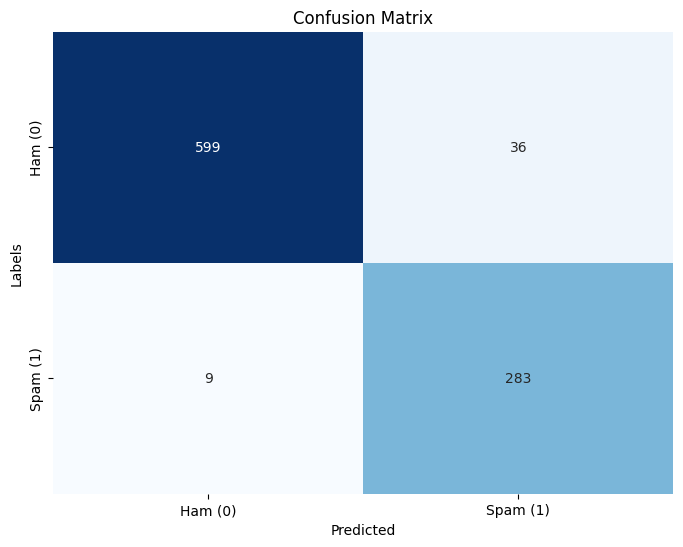

In [ ]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham (0)', 'Spam (1)'],
            yticklabels=['Ham (0)', 'Spam (1)'])

plt.xlabel('Predicted')
plt.ylabel('Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the Naive Bayes model
joblib.dump(nb_model, 'nb_model.joblib')

['nb_model.joblib']

##### Phân tích kết quả, vấn đề gặp phải với Naive Bayes
- Mô hình Naive Bayes gần như tối ưu với độ precision, recall, F1_score > 90%.
- Chỉ sổ giữa Spam và Ham gần như bằng nhau, thể hiện việc mô hình không thiên hướng về một loại thư nhất định mà có thể dự đoán chính xác Ham và Spam ngang nhau.
- Naive Bayes vẫn còn hạn chế: mô hình mặc định các từ độc lập ý nghĩa với nhau, vì vậy lọc thư mà bỏ qua ý nghĩa ngữ cảnh.

##### KNN

In [ ]:
def cosine(x1, x2):
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    # 1 - cosine similarity = distance
    return 1 - (dot_product / (norm_x1 * norm_x2 + 1e-9))

def euclidean(x1, x2):
    distance = np.sqrt(np.sum((x1 - x2)**2))
    return distance

def manhattan(x1, x2):
    distance = np.sum(np.abs(x1 - x2))
    return distance

class KNN:
    def __init__(self, k=5, metric='l1'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        # select the distance function based on self.metric
        if self.metric == 'cosine':
            dist_func = cosine
        elif self.metric == 'l2':
            dist_func = euclidean
        else:
            dist_func = manhattan

        # compute the distance
        distances = [dist_func(x, x_train) for x_train in self.X_train]

        # get the closest k
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # majority voye
        most_common = Counter(k_nearest_labels).most_common()
        return most_common[0][0]

In [ ]:
# Training model

max_accuracy = 0
best_k = 0
best_metric = ''

for k in range(1, 10):
  for dist in ['l1', 'l2', 'cosine']:
    knn_model = KNN(k=k, metric=dist)

    knn_model.fit(X_train_resampled, y_train_resampled)

    y_pred = knn_model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)

    if accuracy > max_accuracy:
      max_accuracy = accuracy
      best_k = k
      best_metric = dist

print(f"Best K: {best_k}\nBest Metric: {best_metric}\nAccuracy: {max_accuracy}")

Best K: 1
Best Metric: cosine
Accuracy: 0.8394062078272605


In [ ]:
# Predict

knn_model = KNN(k=best_k, metric=best_metric)
knn_model.fit(X_train_resampled, y_train_resampled)

y_pred = knn_model.predict(X_test)

In [ ]:
# Evalute performance

accuracy_score(y_test, y_pred)

0.8446601941747572

In [ ]:
# Evaluate the model with classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       635
           1       0.70      0.90      0.79       292

    accuracy                           0.84       927
   macro avg       0.82      0.86      0.83       927
weighted avg       0.87      0.84      0.85       927



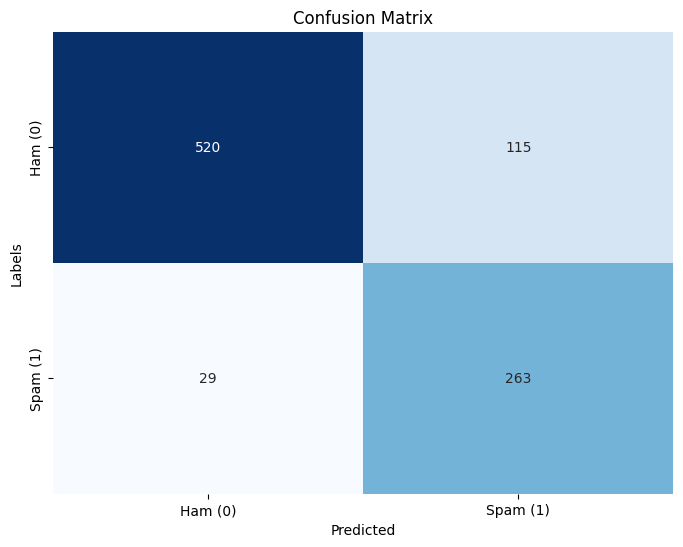

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham (0)', 'Spam (1)'],
            yticklabels=['Ham (0)', 'Spam (1)'])

plt.xlabel('Predicted')
plt.ylabel('Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the KNN model
joblib.dump(knn_model, 'knn_model.joblib')

['knn_model.joblib']

##### Phân tích kết quả, vấn đề gặp phải với KNN
- Ham có precision 95% thể hiện tỉ lệ dự đoán chính xác mail Ham rất cao nhưng recall 82% thể hiện bỏ lỡ 18% số mail Ham trong tổng thể
- Spam có precision 70% thể hiện mô hình dự đoán mail Spam với độ chính xác thấp hơn Ham, nhưng lại tìm được 90% tổng số mail Spam trong tổng thể, cao hơn với Ham.
- Ý nghĩa precision và recall: mô hình KNN có xu hướng "bắt hết" các mail Spam (vì precision thấp nhưng tổng thể recall cao) nhưng tỉ lệ sai cao.


## 4. Cập nhật kết quả cuối kỳ (W15)

### Chi tiết phương pháp, dữ liệu
Thiết lập giao diện cho hệ thống sử dụng thư viện Streamlit

### Chương trình

In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import re
from collections import Counter

class Naive_Bayes:
    def __init__(self, laplace_smoothing=1.0):
        # Hệ số làm trơn để tránh lỗi nhân cho 0
        self.laplace_smoothing = laplace_smoothing

        # Lưu xác suất tiên nghiệm P(c) - VD: P(Spam), P(Ham)
        self.prior_probs = {}

        # Lưu log xác suất có điều kiện log P(w|c) cho từng từ trong từng lớp
        self.log_likelihood = {}

        # Danh sách các nhãn [0, 1]
        self.classes = []

    def fit(self, X, y):
        n_samples, n_features = X.shape # Số dòng (email), Số cột (từ)
        self.classes = np.unique(y)     # Tìm các nhãn duy nhất: [0, 1]

        for c in self.classes:
            # Lấy tất cả các dòng email thuộc nhãn c (VD: Lấy hết Spam)
            X_c = X[y == c]

            # P(c) = Số lượng email lớp c / Tổng số email
            self.prior_probs[c] = X_c.shape[0] / n_samples

            # Tổng số lần xuất hiện của TỪNG từ trong toàn bộ email lớp c
            # word_counts: Mảng 1 chiều chứa tổng từng cột
            word_counts = np.sum(X_c, axis=0) + self.laplace_smoothing

            # Tổng số từ (tất cả các từ) trong lớp c + phần bù Laplace
            total_counts = np.sum(word_counts)

            # Tính Log xác suất để tránh số quá nhỏ (Underflow)
            # log( P(w|c) )
            self.log_likelihood[c] = np.log(word_counts / total_counts)

    def predict(self, X):
        result = [self._predict_single(x) for x in X]
        return np.array(result)

    def _predict_single(self, x):
        best_posterior = -np.inf
        best_class = None

        for c in self.classes:
            # log P(c|x) ∝ log P(c) + Σ (tần_suất_từ * log P(từ|c))

            # Lấy Log Tiên nghiệm (log P(c))
            log_prior = np.log(self.prior_probs[c])

            # Phép nhân vô hướng (Dot product) giữa tần suất từ trong x và log xác suất đã học
            # x * log_likelihood tương đương với việc cộng dồn log xác suất của từng từ
            log_likelihood_sum = np.dot(x, self.log_likelihood[c])

            # Tính Log Hậu nghiệm
            posterior = log_prior + log_likelihood_sum

            # Tìm lớp có xác suất lớn nhất
            if posterior > best_posterior:
                best_posterior = posterior
                best_class = c

        return best_class

def cosine(x1, x2):
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    # 1 - cosine similarity = distance
    return 1 - (dot_product / (norm_x1 * norm_x2 + 1e-9))

def euclidean(x1, x2):
    distance = np.sqrt(np.sum((x1 - x2)**2))
    return distance

def manhattan(x1, x2):
    distance = np.sum(np.abs(x1 - x2))
    return distance

class KNN:
    def __init__(self, k=5, metric='l1'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        # select the distance function based on self.metric
        if self.metric == 'cosine':
            dist_func = cosine
        elif self.metric == 'l2':
            dist_func = euclidean
        else:
            dist_func = manhattan

        # compute the distance
        distances = [dist_func(x, x_train) for x_train in self.X_train]

        # get the closest k
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # majority voye
        most_common = Counter(k_nearest_labels).most_common()
        return most_common[0][0]

@st.cache_data
def load_vocabulary():
    df = pd.read_csv('/content/drive/MyDrive/emails.csv')
    # Get all column names except 'Email No.' and 'Prediction'
    vocabulary = [col for col in df.columns if col not in ['Email No.', 'Prediction']]
    return vocabulary

@st.cache_resource
def load_models():
    # Load model
    nb = joblib.load('nb_model.joblib')
    knn = joblib.load('knn_model.joblib')
    return nb, knn

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Extract words (alphanumeric sequences)
    words = re.findall(r'\b[a-z]+\b', text)
    return words

def text_to_feature_vector(text, vocabulary):
    # Preprocess text to get words
    words = preprocess_text(text)

    # Count word frequencies
    word_counts = Counter(words)

    # Create feature vector
    feature_vector = []
    for word in vocabulary:
        feature_vector.append(word_counts.get(word, 0))

    return np.array(feature_vector)

def main():
    models = load_models()
    vocabulary = load_vocabulary()

    st.set_page_config(page_title="Spam Classifier", layout="centered")

    st.title("Email Spam Classifier")
    st.write("---")

    # Model selector
    algorithm = st.selectbox(
        "Select Algorithm:",
        ("Naive Bayes", "K-Nearest Neighbors")
    )

    st.write("---")

    # Input area
    st.subheader("Enter Email to Check")
    email_input = st.text_area("Email:", height=150, placeholder="Example: Congratulations! You won a prize...")

    # Button
    if st.button("Classify Now", type="primary"):
        if not email_input:
            st.warning("Please enter email before checking.")
        else:
            # Select model
            if algorithm == "Naive Bayes":
                model = models[0]
            else:
                model = models[1]

            # Preprocess input text to feature vector
            feature_vector = text_to_feature_vector(email_input, vocabulary)

            # Prediction
            prediction = model.predict([feature_vector])[0]

            # Result
            st.write("---")
            st.subheader("Result:")

            if prediction == 1:
                st.error("THIS IS SPAM EMAIL")
            else:
                st.success("THIS IS LEGITIMATE EMAIL")

if __name__ == '__main__':
    main()

Writing app.py


In [ ]:
# Password
!wget -q -O - ipv4.icanhazip.com

34.85.176.16


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-28 02:05:49.042 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.85.176.16:8501



### Phân tích, so sánh hiệu quả KNN và Naive Bayes
- Nhìn chung, thuật toán Naive Bayes hiệu quả hơn KNN trong việc phân loại và lọc thư rác (Ham/Spam) với chỉ số F1 cao hơn (0.9 > 0.8).
- Mô hình Naive Bayes dự đoán chính xác mail Ham và Spam cân bằng hơn, KNN dự đoán chính xác mail Spam cao hơn Ham nhưng với độ chính xác thấp hơn.
- Tổng thể classification report KNN cho Precision Ham và Recall Spam cao hơn nhưng không đáng kể, trong khi đó Naive Bayes cho mọi chỉ số > 90%, thể hiện mô hình dự đoán chính xác cao hơn và nhiều mail dự đoán đúng hơn.
- Với training data cân bằng sau khi undersample, việc accuracy của Naive Bayes (95%) > accuracy của KNN (84%) cũng thể hiện thuật toán Naive Bayes hiệu quả rõ rệt hơn.
- KNN có thời gian chạy chậm hơn nhiều so với Naive Bayes; KNN sử dụng nhiều tài nguyên hơn Naive Bayes. Vì vậy KNN không phù hợp xử lý tập dữ liệu lớn.
- Thuật toán KNN hiện tại (chưa cải tiến) còn nhiều hạn chế: chưa đề ra một cách chọn giá trị k tối ưu nhất; đề xuất 3 metrics tính khoảng cách khác nhau (Euclide, Manhattan, Cosine) nhưng chưa trình bày so sánh độ hiệu quả giữa 3 metrics trong chương trình.

